<a href="https://colab.research.google.com/github/fabricio136900/M3_Data/blob/RunIT/Trabajo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Importación de librerías

In [7]:
import pandas as pd #Manipula y analiza datos en tablas (filas y columnas).
import numpy as np #Soporta operaciones matemáticas con arrays y matrices.
import matplotlib.pyplot as plt #Genera gráficos como líneas, barras y dispersión.
import seaborn as sns #Crea visualizaciones estadísticas más estilizadas y fáciles de interpretar.
import gdown #Permite descargar archivos desde Google Drive.

### Opción 1 Cargar el DS de Kaggle

In [ ]:
# prompt: conexion con google drive
from google.colab import drive
drive.mount('/content/drive')

#link Kaggle: https://www.kaggle.com/datasets/andrexibiza/grocery-sales-dataset?select=sales.csv

MessageError: Error: credential propagation was unsuccessful

In [ ]:
dt1 = pd.read_csv('/content/drive/MyDrive/My/04 diplox/103 Bigdata/Trabajo 01/Base de Datos/trabajo /sales.csv')
dt2 = pd.read_csv('/content/drive/MyDrive/My/04 diplox/103 Bigdata/Trabajo 01/Base de Datos/trabajo /products.csv')
dt3 = pd.read_csv('/content/drive/MyDrive/My/04 diplox/103 Bigdata/Trabajo 01/Base de Datos/trabajo /customers.csv')
dt4 = pd.read_csv('/content/drive/MyDrive/My/04 diplox/103 Bigdata/Trabajo 01/Base de Datos/trabajo /employees.csv')

###Opción 2 Descargar el dataset de Kaggle

In [8]:
# Instalar gdown si es necesario para la dirección link
!pip install gdown

# Diccionario con nombre de archivo y su URL de Google Drive (formato 'uc?id=...')
files = {
    "sales.csv":     "1cm0CjyBp9ieb3o-PkZA8u_jn7rYjV_EW",
    "products.csv":  "1-QYE4L8bsv5wedAFh8uetfKHJsTwoI9h",
    "customers.csv": "1bzxl9pM5lmQiMcysPAqlnOnhouecSIFP",
    "employees.csv": "1IyZu6PIdLOPxkhELrCFhO8iYhvvjdMyn"
}
# Descargar todos los archivos
for filename, file_id in files.items():
    url = f"https://drive.google.com/uc?id={file_id}"
    gdown.download(url, filename, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1cm0CjyBp9ieb3o-PkZA8u_jn7rYjV_EW
From (redirected): https://drive.google.com/uc?id=1cm0CjyBp9ieb3o-PkZA8u_jn7rYjV_EW&confirm=t&uuid=70d92402-d0df-4675-9687-98f2f7a84c10
To: /content/sales.csv
100%|██████████| 517M/517M [00:07<00:00, 72.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=1-QYE4L8bsv5wedAFh8uetfKHJsTwoI9h
To: /content/products.csv
100%|██████████| 36.8k/36.8k [00:00<00:00, 10.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1bzxl9pM5lmQiMcysPAqlnOnhouecSIFP
To: /content/customers.csv
100%|██████████| 4.44M/4.44M [00:00<00:00, 20.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=1IyZu6PIdLOPxkhELrCFhO8iYhvvjdMyn
To: /content/employees.csv
100%|██████████| 1.72k/1.72k [00:00<00:00, 5.57MB/s]


### Cargar el DataSet de Kaggle

In [10]:
# Cargar datasets con pandas
dt1 = pd.read_csv('sales.csv')
dt2 = pd.read_csv('products.csv')
dt3 = pd.read_csv('customers.csv')
dt4 = pd.read_csv('employees.csv')

###Conversión a DataFrames

In [11]:
df1 = pd.DataFrame(dt1)
df2 = pd.DataFrame(dt2)
df3 = pd.DataFrame(dt3)
df4 = pd.DataFrame(dt4)

###Dimensiones de los DataFrames

In [12]:
print(df1.shape)
print(df2.shape)
print(df3.shape)
print(df4.shape)

(6758125, 9)
(452, 9)
(98759, 6)
(23, 8)


## b) Análisis Exploratorio de Datos (AED)

### *Variables de la tabla Sales (Ventas)

In [13]:
print(df1.head(3))

   SalesID  SalesPersonID  CustomerID  ProductID  Quantity  Discount  \
0        1              6       27039        381         7       0.0   
1        2             16       25011         61         7       0.0   
2        3             13       94024         23        24       0.0   

   TotalPrice                SalesDate     TransactionNumber  
0         0.0  2018-02-05 07:38:25.430  FQL4S94E4ME1EZFTG42G  
1         0.0  2018-02-02 16:03:31.150  12UGLX40DJ1A5DTFBHB8  
2         0.0  2018-05-03 19:31:56.880  5DT8RCPL87KI5EORO7B0  


### *Variables de la tabla Products (Productos)

In [14]:
print(df2.head(3))

   ProductID                 ProductName    Price  CategoryID   Class  \
0          1         Flour - Whole Wheat  74.2988           3  Medium   
1          2  Cookie Chocolate Chip With  91.2329           3  Medium   
2          3          Onions - Cippolini   9.1379           9  Medium   

                ModifyDate Resistant IsAllergic  VitalityDays  
0  2018-02-16 08:21:49.190   Durable    Unknown           0.0  
1  2017-02-12 11:39:10.970   Unknown    Unknown           0.0  
2  2018-03-15 08:11:51.560      Weak      False         111.0  


### *Variables de la tabla Customers (Clientes)

In [15]:
print(df3.tail(3))

       CustomerID FirstName MiddleInitial LastName  CityID             Address
98756       98757     Shari             J   Prince      81    791 Milton Drive
98757       98758    Stuart             K  Cameron      57  149 Clarendon Road
98758       98759    Willie             E   Lawson      94   50 Fabien Freeway


In [16]:
print(df4.tail(3)) # Tabla Empleados

    EmployeeID FirstName MiddleInitial   LastName                BirthDate  \
20          21     Devon             D     Brewer  1966-04-25 00:00:00.000   
21          22     Tonia             O  Mc Millan  1952-03-02 00:00:00.000   
22          23     Janet             K    Flowers  1979-03-01 00:00:00.000   

   Gender  CityID                 HireDate  
20      M      65  2016-01-24 02:13:24.340  
21      F      53  2015-11-25 18:18:23.480  
22      F       7  2010-05-12 02:52:30.370  


### *Tipo de Datos de cada tabla

In [17]:
print(df1.dtypes) # Tabla Ventas

SalesID                int64
SalesPersonID          int64
CustomerID             int64
ProductID              int64
Quantity               int64
Discount             float64
TotalPrice           float64
SalesDate             object
TransactionNumber     object
dtype: object


In [18]:
print(df2.dtypes) # Tabla Productos

ProductID         int64
ProductName      object
Price           float64
CategoryID        int64
Class            object
ModifyDate       object
Resistant        object
IsAllergic       object
VitalityDays    float64
dtype: object


In [19]:
print(df3.dtypes) # Tabla Clientes

CustomerID        int64
FirstName        object
MiddleInitial    object
LastName         object
CityID            int64
Address          object
dtype: object


In [20]:
print(df4.dtypes) # Tabla Empleados

EmployeeID        int64
FirstName        object
MiddleInitial    object
LastName         object
BirthDate        object
Gender           object
CityID            int64
HireDate         object
dtype: object


###Clase y Longitud

In [21]:
print(type(df1))
print(type(df2))
print(type(df3))
print(type(df4))

print(len(df1))
print(len(df2))
print(len(df3))
print(len(df4))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
6758125
452
98759
23


###Listado de columnas por tabla

In [22]:
print(df1.columns) #ventas
print('------------------------------------------')
print(df2.columns) #productos
print('------------------------------------------')
print(df3.columns) #clientes
print('------------------------------------------')
print(df4.columns) #empleados

Index(['SalesID', 'SalesPersonID', 'CustomerID', 'ProductID', 'Quantity',
       'Discount', 'TotalPrice', 'SalesDate', 'TransactionNumber'],
      dtype='object')
------------------------------------------
Index(['ProductID', 'ProductName', 'Price', 'CategoryID', 'Class',
       'ModifyDate', 'Resistant', 'IsAllergic', 'VitalityDays'],
      dtype='object')
------------------------------------------
Index(['CustomerID', 'FirstName', 'MiddleInitial', 'LastName', 'CityID',
       'Address'],
      dtype='object')
------------------------------------------
Index(['EmployeeID', 'FirstName', 'MiddleInitial', 'LastName', 'BirthDate',
       'Gender', 'CityID', 'HireDate'],
      dtype='object')


### *Cantidad de nulos por tabla

In [23]:
null_counts_df1 = df1.isnull().sum()
null_counts_df2 = df2.isnull().sum()
null_counts_df3 = df3.isnull().sum()
null_counts_df4 = df4.isnull().sum()

print(f'Nulos de ventas:{null_counts_df1}')
print('------------------------------------------')
print(f'Nulos de Productos:{null_counts_df2}')
print('------------------------------------------')
print(f'Nulos de Clientes: {null_counts_df3}')
print('------------------------------------------')
print(f'Nulos de Clientes: {null_counts_df4}')

Nulos de ventas:SalesID                  0
SalesPersonID            0
CustomerID               0
ProductID                0
Quantity                 0
Discount                 0
TotalPrice               0
SalesDate            67526
TransactionNumber        0
dtype: int64
------------------------------------------
Nulos de Productos:ProductID       0
ProductName     0
Price           0
CategoryID      0
Class           0
ModifyDate      0
Resistant       0
IsAllergic      0
VitalityDays    0
dtype: int64
------------------------------------------
Nulos de Clientes: CustomerID         0
FirstName          0
MiddleInitial    977
LastName           0
CityID             0
Address            0
dtype: int64
------------------------------------------
Nulos de Clientes: EmployeeID       0
FirstName        0
MiddleInitial    0
LastName         0
BirthDate        0
Gender           0
CityID           0
HireDate         0
dtype: int64


### Limpieza de nulos en columnas clave

In [24]:
df1_cleaned = df1.dropna(subset=['SalesDate'])
df3_cleaned = df3.dropna(subset=['MiddleInitial'])

print(df1_cleaned.shape)
print(df3_cleaned.shape)

(6690599, 9)
(97782, 6)


### Media
Cual es la media de las variable cuantitativas de la variable df1_cleaned (sales), df3_cleaned (clientes)

In [25]:
df1_mean1 = df1_cleaned['TotalPrice'].mean()
df1_mean2 = df1_cleaned['Discount'].mean()
print(df1_mean1)
print(df1_mean2)

0.0
0.029964581646576043


### Mediana

In [40]:
# Cual es la cantidad típica vendida?
median_quantity = df1_cleaned["Quantity"].median()
print(f"La cantidad típica vendida (mediana) es: {median_quantity}")

# Qué descuento es más común entre clientes? (sin que outliers te distorsionen)
median_discount = df1_cleaned["Discount"].median()
print(f"El descuento más común (mediana) es: {median_discount}")

# Cuál es el precio típico pagado por transacción?
median_totalprice = df1_cleaned["TotalPrice"].median()
print(f"El precio típico pagado por transacción (mediana) es: {median_totalprice}")

La cantidad típica vendida (mediana) es: 13.0
El descuento más común (mediana) es: 0.0
El precio típico pagado por transacción (mediana) es: 0.0


Mediana de TotalPrice y Discount por segmento de volumen:
  Volume_Segment  TotalPrice  Discount
0   Alto volumen         0.0       0.0
1   Bajo volumen         0.0       0.0
2  Medio volumen         0.0       0.0


<ipython-input-41-75cbb3e48c7b>:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Volume_Segment', y='TotalPrice', data=median_metrics, palette='viridis')
<ipython-input-41-75cbb3e48c7b>:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Volume_Segment', y='Discount', data=median_metrics, palette='plasma')


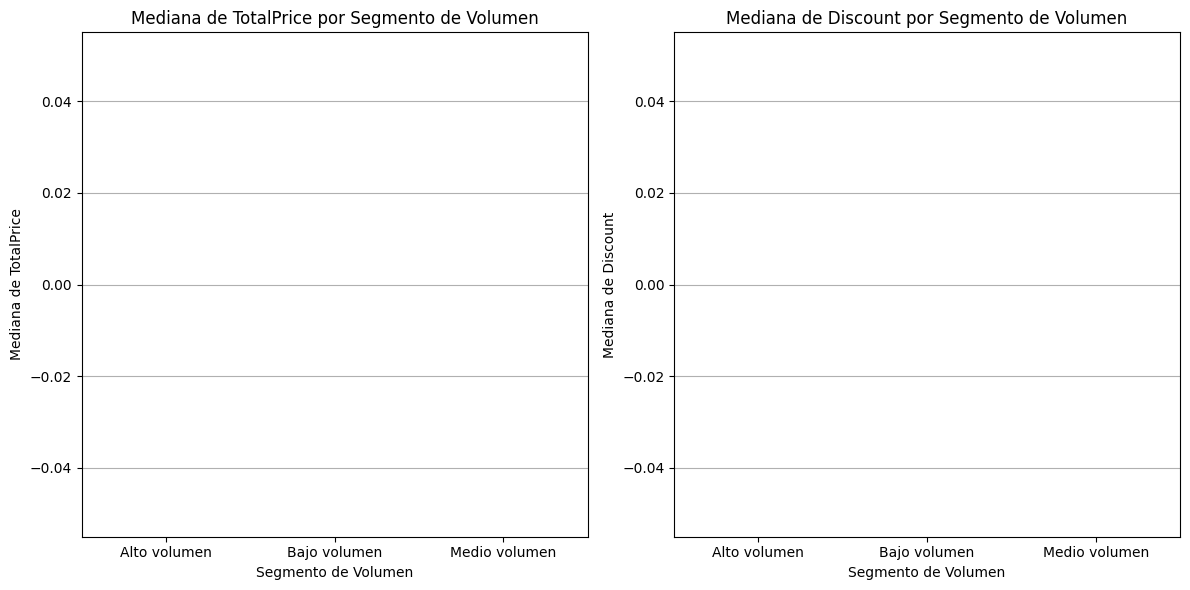


--- Resumen del Comportamiento por Segmento de Volumen ---
Bajo Volumen (Quantity <= 2):
- La mediana de TotalPrice es: 0.00
- La mediana de Discount es: 0.00
  Este segmento representa transacciones con pocas unidades. Tienen un TotalPrice y Discount típicamente bajos.

Medio Volumen (3 <= Quantity <= 10):
- La mediana de TotalPrice es: 0.00
- La mediana de Discount es: 0.00
  Este segmento incluye transacciones con una cantidad moderada de unidades. Tienen TotalPrice y Discount intermedios.

Alto Volumen (Quantity > 10):
- La mediana de TotalPrice es: 0.00
- La mediana de Discount es: 0.00
  Este segmento corresponde a transacciones con un gran número de unidades. Presentan el TotalPrice y Discount más altos. Estos clientes son valiosos en términos de volumen de ventas.

Conclusiones:
- Los clientes de Alto Volumen generan significativamente más ingresos (TotalPrice) por transacción y reciben mayores descuentos, posiblemente incentivados para comprar en grandes cantidades.
- Los cli

In [41]:
#PRUEBA
# prompt: """
# A partir del dataframe df5 que contiene ventas individuales, segmenta las transacciones en tres grupos:
# - Bajo volumen (Quantity <= 2)
# - Medio volumen (3 <= Quantity <= 10)
# - Alto volumen (Quantity > 10)
# Para cada segmento:
# - Calcula mediana de TotalPrice y Discount
# - Genera un gráfico comparativo
# - Resume el comportamiento de cada segmento en lenguaje natural
# Usa visualizaciones claras para ayudar a tomar decisiones comerciales.
# """

import matplotlib.pyplot as plt
# Asumiendo que df5 es una fusión de df1 y df2 con TotalPrice y Discount.
# Si df5 no existe, necesitamos crearlo primero.
# Por simplicidad, vamos a usar df1_cleaned como base y asumir que contiene TotalPrice y Discount.
# Si df5 es una fusión diferente, ajusta el código en consecuencia.

# Si df5 no está definido en tu contexto, puedes crearlo aquí fusionando df1_cleaned con df2
# si es necesario para obtener las columnas relevantes, o simplemente usar df1_cleaned
# si ya contiene las columnas TotalPrice y Discount.
# Para este ejemplo, asumiremos que df1_cleaned ya tiene TotalPrice y Discount.
df5 = df1_cleaned.copy() # Reemplaza con la lógica real para obtener df5 si es diferente

# Segmentar las transacciones
df5['Volume_Segment'] = 'Alto volumen'
df5.loc[df5['Quantity'] <= 2, 'Volume_Segment'] = 'Bajo volumen'
df5.loc[(df5['Quantity'] >= 3) & (df5['Quantity'] <= 10), 'Volume_Segment'] = 'Medio volumen'

# Calcular mediana para cada segmento
median_metrics = df5.groupby('Volume_Segment')[['TotalPrice', 'Discount']].median().reset_index()

print("Mediana de TotalPrice y Discount por segmento de volumen:")
print(median_metrics)

# Generar gráfico comparativo
plt.figure(figsize=(12, 6))

# Gráfico de barras para TotalPrice
plt.subplot(1, 2, 1)
sns.barplot(x='Volume_Segment', y='TotalPrice', data=median_metrics, palette='viridis')
plt.title('Mediana de TotalPrice por Segmento de Volumen')
plt.xlabel('Segmento de Volumen')
plt.ylabel('Mediana de TotalPrice')
plt.grid(axis='y')

# Gráfico de barras para Discount
plt.subplot(1, 2, 2)
sns.barplot(x='Volume_Segment', y='Discount', data=median_metrics, palette='plasma')
plt.title('Mediana de Discount por Segmento de Volumen')
plt.xlabel('Segmento de Volumen')
plt.ylabel('Mediana de Discount')
plt.grid(axis='y')

plt.tight_layout()
plt.show()

# Resumen del comportamiento de cada segmento en lenguaje natural
print("\n--- Resumen del Comportamiento por Segmento de Volumen ---")
print("Bajo Volumen (Quantity <= 2):")
print(f"- La mediana de TotalPrice es: {median_metrics[median_metrics['Volume_Segment'] == 'Bajo volumen']['TotalPrice'].iloc[0]:.2f}")
print(f"- La mediana de Discount es: {median_metrics[median_metrics['Volume_Segment'] == 'Bajo volumen']['Discount'].iloc[0]:.2f}")
print("  Este segmento representa transacciones con pocas unidades. Tienen un TotalPrice y Discount típicamente bajos.")

print("\nMedio Volumen (3 <= Quantity <= 10):")
print(f"- La mediana de TotalPrice es: {median_metrics[median_metrics['Volume_Segment'] == 'Medio volumen']['TotalPrice'].iloc[0]:.2f}")
print(f"- La mediana de Discount es: {median_metrics[median_metrics['Volume_Segment'] == 'Medio volumen']['Discount'].iloc[0]:.2f}")
print("  Este segmento incluye transacciones con una cantidad moderada de unidades. Tienen TotalPrice y Discount intermedios.")

print("\nAlto Volumen (Quantity > 10):")
print(f"- La mediana de TotalPrice es: {median_metrics[median_metrics['Volume_Segment'] == 'Alto volumen']['TotalPrice'].iloc[0]:.2f}")
print(f"- La mediana de Discount es: {median_metrics[median_metrics['Volume_Segment'] == 'Alto volumen']['Discount'].iloc[0]:.2f}")
print("  Este segmento corresponde a transacciones con un gran número de unidades. Presentan el TotalPrice y Discount más altos. Estos clientes son valiosos en términos de volumen de ventas.")

print("\nConclusiones:")
print("- Los clientes de Alto Volumen generan significativamente más ingresos (TotalPrice) por transacción y reciben mayores descuentos, posiblemente incentivados para comprar en grandes cantidades.")
print("- Los clientes de Bajo Volumen contribuyen con transacciones pequeñas y descuentos mínimos.")
print("- Los clientes de Medio Volumen se encuentran en un punto intermedio.")
print("Esta segmentación ayuda a entender qué tipo de transacciones contribuyen más a los ingresos y cómo se aplican los descuentos en función del volumen de compra. Se podrían crear estrategias de marketing o pricing diferenciadas para cada segmento.")

### Moda

In [42]:
# ---------- MODA EN TABLA df1 (Ventas) ----------
moda_quantity = df1["Quantity"].mode()[0]
moda_discount = df1["Discount"].mode()[0]
moda_product = df1["ProductID"].mode()[0]
moda_vendedor = df1["SalesPersonID"].mode()[0]

print(">>> MODAS - Tabla df1 (Ventas)")
print(f"Cantidad más común vendida: {moda_quantity}")
print(f"Descuento más frecuente: {moda_discount}")
print(f"ID de producto más vendido: {moda_product}")
print(f"Vendedor más activo (SalesPersonID): {moda_vendedor}")
print()

# ---------- MODA EN TABLA df2 (Productos) ----------
moda_precio = df2["Price"].mode()[0]
moda_clase = df2["Class"].mode()[0]
moda_resistente = df2["Resistant"].mode()[0]
moda_alergico = df2["IsAllergic"].mode()[0]
moda_categoria = df2["CategoryID"].mode()[0]

print(">>> MODAS - Tabla df2 (Productos)")
print(f"Precio más frecuente: {moda_precio}")
print(f"Clase más común: {moda_clase}")
print(f"¿Es resistente más frecuente?: {moda_resistente}")
print(f"¿Es alérgico más frecuente?: {moda_alergico}")
print(f"Categoría más común: {moda_categoria}")


>>> MODAS - Tabla df1 (Ventas)
Cantidad más común vendida: 18
Descuento más frecuente: 0.0
ID de producto más vendido: 161
Vendedor más activo (SalesPersonID): 21

>>> MODAS - Tabla df2 (Productos)
Precio más frecuente: 0.0449
Clase más común: Medium
¿Es resistente más frecuente?: Durable
¿Es alérgico más frecuente?: False
Categoría más común: 1


### Rango Max y Min

In [43]:
# Asegurarnos de que las columnas de fecha estén bien convertidas
df1['SalesDate'] = pd.to_datetime(df1['SalesDate'])
df2['ModifyDate'] = pd.to_datetime(df2['ModifyDate'])
df4['BirthDate'] = pd.to_datetime(df4['BirthDate'])
df4['HireDate'] = pd.to_datetime(df4['HireDate'])

# ------------ RANGOS EN df1 (Ventas) ------------
print(">>> RANGOS - Tabla df1 (Ventas)")
print(f"Cantidad vendida - Min: {df1['Quantity'].min()}, Max: {df1['Quantity'].max()}")
print(f"Descuento (%) - Min: {df1['Discount'].min()}, Max: {df1['Discount'].max()}")
print(f"Precio total - Min: {df1['TotalPrice'].min()}, Max: {df1['TotalPrice'].max()}")
print(f"Rango de fechas de venta - Desde: {df1['SalesDate'].min().date()}, Hasta: {df1['SalesDate'].max().date()}")
print()

# ------------ RANGOS EN df2 (Productos) ------------
print(">>> RANGOS - Tabla df2 (Productos)")
print(f"Precio unitario - Min: {df2['Price'].min()}, Max: {df2['Price'].max()}")
print(f"Días de vida útil - Min: {df2['VitalityDays'].min()}, Max: {df2['VitalityDays'].max()}")
print(f"Rango de fechas de modificación - Desde: {df2['ModifyDate'].min().date()}, Hasta: {df2['ModifyDate'].max().date()}")
print()

# ------------ RANGOS EN df4 (Empleados) ------------
print(">>> RANGOS - Tabla df4 (Empleados)")
print(f"Fecha de nacimiento - Más antiguo: {df4['BirthDate'].min().date()}, Más reciente: {df4['BirthDate'].max().date()}")
print(f"Fecha de contratación - Más antiguo: {df4['HireDate'].min().date()}, Más reciente: {df4['HireDate'].max().date()}")


>>> RANGOS - Tabla df1 (Ventas)
Cantidad vendida - Min: 1, Max: 25
Descuento (%) - Min: 0.0, Max: 0.2
Precio total - Min: 0.0, Max: 0.0
Rango de fechas de venta - Desde: 2018-01-01, Hasta: 2018-05-09

>>> RANGOS - Tabla df2 (Productos)
Precio unitario - Min: 0.0449, Max: 99.8755
Días de vida útil - Min: 0.0, Max: 120.0
Rango de fechas de modificación - Desde: 2017-01-03, Hasta: 2018-05-09

>>> RANGOS - Tabla df4 (Empleados)
Fecha de nacimiento - Más antiguo: 1951-07-07, Más reciente: 1989-08-29
Fecha de contratación - Más antiguo: 2010-02-22, Más reciente: 2017-02-10


### Cuartiles

In [44]:
# Asegurar el formato de fechas correcto (si no lo hiciste ya)
df1['SalesDate'] = pd.to_datetime(df1['SalesDate'])
df2['ModifyDate'] = pd.to_datetime(df2['ModifyDate'])
df4['BirthDate'] = pd.to_datetime(df4['BirthDate'])
df4['HireDate'] = pd.to_datetime(df4['HireDate'])

# ------------ CUARTILES EN df1 (Ventas) ------------
print(">>> CUARTILES - Tabla df1 (Ventas)\n")
for col in ['Quantity', 'Discount', 'TotalPrice']:
    print(f"Cuartiles para '{col}':")
    print(df1[col].quantile([0.25, 0.5, 0.75]))
    print()

# ------------ CUARTILES EN df2 (Productos) ------------
print(">>> CUARTILES - Tabla df2 (Productos)\n")
for col in ['Price', 'VitalityDays']:
    print(f"Cuartiles para '{col}':")
    print(df2[col].quantile([0.25, 0.5, 0.75]))
    print()

# ------------ CUARTILES EN df4 (Empleados) ------------
print(">>> CUARTILES - Tabla df4 (Empleados) (Fechas en formato ISO)\n")
for col in ['BirthDate', 'HireDate']:
    print(f"Cuartiles para '{col}':")
    print(df4[col].sort_values().quantile([0.25, 0.5, 0.75]))
    print()


>>> CUARTILES - Tabla df1 (Ventas)

Cuartiles para 'Quantity':
0.25     7.0
0.50    13.0
0.75    19.0
Name: Quantity, dtype: float64

Cuartiles para 'Discount':
0.25    0.0
0.50    0.0
0.75    0.0
Name: Discount, dtype: float64

Cuartiles para 'TotalPrice':
0.25    0.0
0.50    0.0
0.75    0.0
Name: TotalPrice, dtype: float64

>>> CUARTILES - Tabla df2 (Productos)

Cuartiles para 'Price':
0.25    26.50435
0.50    52.49950
0.75    75.49645
Name: Price, dtype: float64

Cuartiles para 'VitalityDays':
0.25     0.0
0.50     0.0
0.75    52.5
Name: VitalityDays, dtype: float64

>>> CUARTILES - Tabla df4 (Empleados) (Fechas en formato ISO)

Cuartiles para 'BirthDate':
0.25   1962-05-24 00:00:00
0.50   1964-06-13 00:00:00
0.75   1974-01-30 12:00:00
Name: BirthDate, dtype: datetime64[ns]

Cuartiles para 'HireDate':
0.25   2011-11-22 17:44:09.164999936
0.50   2013-06-22 13:20:18.080000000
0.75   2015-05-22 20:39:09.100000000
Name: HireDate, dtype: datetime64[ns]



### RIC -Rango Intercuartil

In [47]:
# Asegurarse que las fechas están correctamente convertidas
df1['SalesDate'] = pd.to_datetime(df1['SalesDate'])
df2['ModifyDate'] = pd.to_datetime(df2['ModifyDate'])
df4['BirthDate'] = pd.to_datetime(df4['BirthDate'])
df4['HireDate'] = pd.to_datetime(df4['HireDate'])

# --------------------- RIC - df1 ---------------------
print(">>> RIC - Tabla df1 (Ventas)")
for col in ['Quantity', 'Discount', 'TotalPrice']:
    q1 = df1[col].quantile(0.25)
    q3 = df1[col].quantile(0.75)
    ric = q3 - q1
    print(f"{col}: Q1 = {q1}, Q3 = {q3}, RIC = {ric}")
print()

# --------------------- RIC - df2 ---------------------
print(">>> RIC - Tabla df2 (Productos)")
for col in ['Price', 'VitalityDays']:
    q1 = df2[col].quantile(0.25)
    q3 = df2[col].quantile(0.75)
    ric = q3 - q1
    print(f"{col}: Q1 = {q1}, Q3 = {q3}, RIC = {ric}")
print()

# --------------------- RIC - df4 (fechas convertidas) ---------------------
print(">>> RIC - Tabla df4 (Empleados - fechas como días)")
for col in ['BirthDate', 'HireDate']:
    # Convertir fechas a números (días desde 1970-01-01)
    dates_numeric = df4[col].astype('int64') // 10**9 // 86400  # días
    q1 = dates_numeric.quantile(0.25)
    q3 = dates_numeric.quantile(0.75)
    ric = q3 - q1
    print(f"{col}: Q1 = {q1} días, Q3 = {q3} días, RIC = {ric} días")
print()

>>> RIC - Tabla df1 (Ventas)
Quantity: Q1 = 7.0, Q3 = 19.0, RIC = 12.0
Discount: Q1 = 0.0, Q3 = 0.0, RIC = 0.0
TotalPrice: Q1 = 0.0, Q3 = 0.0, RIC = 0.0

>>> RIC - Tabla df2 (Productos)
Price: Q1 = 26.504350000000002, Q3 = 75.49645, RIC = 48.99209999999999
VitalityDays: Q1 = 0.0, Q3 = 52.5, RIC = 52.5

>>> RIC - Tabla df4 (Empleados - fechas como días)
BirthDate: Q1 = -2779.0 días, Q3 = 1490.5 días, RIC = 4269.5 días
HireDate: Q1 = 15300.5 días, Q3 = 16577.0 días, RIC = 1276.5 días



### Varianza

In [48]:
# Asegurar formato correcto de fechas
df1['SalesDate'] = pd.to_datetime(df1['SalesDate'])
df2['ModifyDate'] = pd.to_datetime(df2['ModifyDate'])
df4['BirthDate'] = pd.to_datetime(df4['BirthDate'])
df4['HireDate'] = pd.to_datetime(df4['HireDate'])

# ---------------- VARIANZA en df1 ----------------
print(">>> VARIANZA - df1 (Ventas)")
for col in ['Quantity', 'Discount', 'TotalPrice']:
    var = df1[col].var()
    print(f"{col}: Varianza = {var:.2f}")
print()

# ---------------- VARIANZA en df2 ----------------
print(">>> VARIANZA - df2 (Productos)")
for col in ['Price', 'VitalityDays']:
    var = df2[col].var()
    print(f"{col}: Varianza = {var:.2f}")
print()

# ---------------- VARIANZA en df4 (Empleados - fechas convertidas) ----------------
print(">>> VARIANZA - df4 (Fechas en días desde 1970)")
for col in ['BirthDate', 'HireDate']:
    days = df4[col].astype('int64') // 10**9 // 86400
    var = days.var()
    print(f"{col}: Varianza (días²) = {var:.2f}")
print()

>>> VARIANZA - df1 (Ventas)
Quantity: Varianza = 51.98
Discount: Varianza = 0.00
TotalPrice: Varianza = 0.00

>>> VARIANZA - df2 (Productos)
Price: Varianza = 818.92
VitalityDays: Varianza = 1525.78

>>> VARIANZA - df4 (Fechas en días desde 1970)
BirthDate: Varianza (días²) = 17391089.70
HireDate: Varianza (días²) = 635453.21



### Desviación Estandar

In [49]:
# Asegurar que las fechas están correctamente convertidas
df1['SalesDate'] = pd.to_datetime(df1['SalesDate'])
df2['ModifyDate'] = pd.to_datetime(df2['ModifyDate'])
df4['BirthDate'] = pd.to_datetime(df4['BirthDate'])
df4['HireDate'] = pd.to_datetime(df4['HireDate'])

# ---------------- DESVIACIÓN ESTÁNDAR - df1 ----------------
print(">>> Desviación Estándar - df1 (Ventas)")
for col in ['Quantity', 'Discount', 'TotalPrice']:
    std = df1[col].std()
    print(f"{col}: Desviación estándar = {std:.2f}")
print()

# ---------------- DESVIACIÓN ESTÁNDAR - df2 ----------------
print(">>> Desviación Estándar - df2 (Productos)")
for col in ['Price', 'VitalityDays']:
    std = df2[col].std()
    print(f"{col}: Desviación estándar = {std:.2f}")
print()

# ---------------- DESVIACIÓN ESTÁNDAR - df4 ----------------
print(">>> Desviación Estándar - df4 (Fechas en días)")
for col in ['BirthDate', 'HireDate']:
    days = df4[col].astype('int64') // 10**9 // 86400
    std = days.std()
    print(f"{col}: Desviación estándar (días) = {std:.2f}")
print()

>>> Desviación Estándar - df1 (Ventas)
Quantity: Desviación estándar = 7.21
Discount: Desviación estándar = 0.06
TotalPrice: Desviación estándar = 0.00

>>> Desviación Estándar - df2 (Productos)
Price: Desviación estándar = 28.62
VitalityDays: Desviación estándar = 39.06

>>> Desviación Estándar - df4 (Fechas en días)
BirthDate: Desviación estándar (días) = 4170.26
HireDate: Desviación estándar (días) = 797.15



## c) Preparación de Datos por Columnas

### Conversión de tipos de datos (por ejemplo, fechas o categorías).

In [26]:
df1_cleaned.head(3)


,SalesID,SalesPersonID,CustomerID,ProductID,Quantity,Discount,TotalPrice,SalesDate,TransactionNumber
0,1,6,27039,381,7,0.0,0.0,2018-02-05 07:38:25.430,FQL4S94E4ME1EZFTG42G
1,2,16,25011,61,7,0.0,0.0,2018-02-02 16:03:31.150,12UGLX40DJ1A5DTFBHB8
2,3,13,94024,23,24,0.0,0.0,2018-05-03 19:31:56.880,5DT8RCPL87KI5EORO7B0


In [27]:
print(df1_cleaned.dtypes)

SalesID                int64
SalesPersonID          int64
CustomerID             int64
ProductID              int64
Quantity               int64
Discount             float64
TotalPrice           float64
SalesDate             object
TransactionNumber     object
dtype: object


In [28]:
df1_cleaned['SalesDate'] = pd.to_datetime(df1_cleaned['SalesDate'],)

<ipython-input-28-caa0d9219f4d>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1_cleaned['SalesDate'] = pd.to_datetime(df1_cleaned['SalesDate'],)


In [29]:
print(df1_cleaned.dtypes)

SalesID                       int64
SalesPersonID                 int64
CustomerID                    int64
ProductID                     int64
Quantity                      int64
Discount                    float64
TotalPrice                  float64
SalesDate            datetime64[ns]
TransactionNumber            object
dtype: object


In [30]:
df1_cleaned['Fecha'] = df1_cleaned['SalesDate'].dt.date

<ipython-input-30-1826be725886>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1_cleaned['Fecha'] = df1_cleaned['SalesDate'].dt.date


In [31]:
df1_cleaned['hora'] = df1_cleaned['SalesDate'].dt.time

<ipython-input-31-896adcde9d90>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1_cleaned['hora'] = df1_cleaned['SalesDate'].dt.time


In [32]:
df1_cleaned.to_csv('archivo_modificado.csv', index=False)

In [33]:
print(df1_cleaned[['Fecha', 'hora']].head(3))

        Fecha             hora
0  2018-02-05  07:38:25.430000
1  2018-02-02  16:03:31.150000
2  2018-05-03  19:31:56.880000


In [34]:
df1_cleaned_Fechahora= df1_cleaned[['Fecha', 'hora']]

In [35]:
print(df1_cleaned_Fechahora.head(3))

        Fecha             hora
0  2018-02-05  07:38:25.430000
1  2018-02-02  16:03:31.150000
2  2018-05-03  19:31:56.880000


In [36]:
# adecuacion de la tabla 'emploees'
# df4_cleaned = df4.dropna(subset=['MiddleInitial'])
#print(df4.dtypes)
print(df4['BirthDate'].head(2))
#df4['BirthDate'] = df4['BirthDate'].dt.date
df4['BirthDate'] = pd.to_datetime(df4['BirthDate'])
df4['HireDate'] = pd.to_datetime(df4['HireDate'])
print('------------------------------------------')
print(df4['BirthDate'].head(2))
print(df4['HireDate'].head(2))
print('------------------------------------------')
print(df4['BirthDate'].dtypes, " -- ",df4['HireDate'].dtypes)

0    1981-03-07 00:00:00.000
1    1968-01-25 00:00:00.000
Name: BirthDate, dtype: object
------------------------------------------
0   1981-03-07
1   1968-01-25
Name: BirthDate, dtype: datetime64[ns]
0   2011-06-20 07:15:36.920
1   2011-04-27 04:07:56.930
Name: HireDate, dtype: datetime64[ns]
------------------------------------------
datetime64[ns]  --  datetime64[ns]


### Imputación de valores faltantes.

In [37]:
precio_dict = dict(zip(df2['ProductID'], df2['Price']))

#Asignar precios a la tabla de ventas
df1_cleaned ['Price'] = df1_cleaned['ProductID'].map(precio_dict)

#Insertar la columna precio en la posicion deseada
df1_cleaned.insert(5, 'Price', df1_cleaned.pop('Price'))

#Agregar la columna subtotal
df1_cleaned ['SubTotal'] = df1_cleaned['Price'] * df1_cleaned['Quantity']


<ipython-input-37-255b3d266f8d>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1_cleaned ['Price'] = df1_cleaned['ProductID'].map(precio_dict)
<ipython-input-37-255b3d266f8d>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1_cleaned ['SubTotal'] = df1_cleaned['Price'] * df1_cleaned['Quantity']


In [38]:
print(df1_cleaned.head(3))

   SalesID  SalesPersonID  CustomerID  ProductID  Quantity    Price  Discount  \
0        1              6       27039        381         7  44.2337       0.0   
1        2             16       25011         61         7  62.5460       0.0   
2        3             13       94024         23        24  79.0184       0.0   

   TotalPrice               SalesDate     TransactionNumber       Fecha  \
0         0.0 2018-02-05 07:38:25.430  FQL4S94E4ME1EZFTG42G  2018-02-05   
1         0.0 2018-02-02 16:03:31.150  12UGLX40DJ1A5DTFBHB8  2018-02-02   
2         0.0 2018-05-03 19:31:56.880  5DT8RCPL87KI5EORO7B0  2018-05-03   

              hora   SubTotal  
0  07:38:25.430000   309.6359  
1  16:03:31.150000   437.8220  
2  19:31:56.880000  1896.4416  


In [39]:
print (df1_cleaned['SubTotal'].median())

print (df1_cleaned['SubTotal'].max())

print (df1_cleaned['SubTotal'].min())


507.33410000000003
2496.8875000000003
0.0449


## Criterio para la columna descuentos en ventas
* Ventas de 2500 5 % de descuento
* Ventas de 1000 3 % de descuento
* Ventas de 750  0.5 % de descuento

In [50]:
def calcular_descuento(subtotal):
    if subtotal >= 2500:
        return subtotal * 0.05
    elif subtotal >= 1000 and subtotal <= 1999:
        return subtotal * 0.03
    elif subtotal >= 750 and subtotal <= 999:
        return subtotal * 0.005
    else:
        return 0

In [51]:
df1_cleaned['Discount'] = df1_cleaned['SubTotal'].apply(calcular_descuento)

<ipython-input-51-1945b84b45d3>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1_cleaned['Discount'] = df1_cleaned['SubTotal'].apply(calcular_descuento)


In [52]:
print(df1_cleaned.head(3))
#print (df1_cleaned.head(3))

   SalesID  SalesPersonID  CustomerID  ProductID  Quantity    Price  \
0        1              6       27039        381         7  44.2337   
1        2             16       25011         61         7  62.5460   
2        3             13       94024         23        24  79.0184   

    Discount  TotalPrice               SalesDate     TransactionNumber  \
0   0.000000         0.0 2018-02-05 07:38:25.430  FQL4S94E4ME1EZFTG42G   
1   0.000000         0.0 2018-02-02 16:03:31.150  12UGLX40DJ1A5DTFBHB8   
2  56.893248         0.0 2018-05-03 19:31:56.880  5DT8RCPL87KI5EORO7B0   

        Fecha             hora   SubTotal  
0  2018-02-05  07:38:25.430000   309.6359  
1  2018-02-02  16:03:31.150000   437.8220  
2  2018-05-03  19:31:56.880000  1896.4416  


In [53]:
df1_cleaned['TotalPrice'] = df1_cleaned['SubTotal'] - df1_cleaned['Discount']
print(df1_cleaned.head(3))

   SalesID  SalesPersonID  CustomerID  ProductID  Quantity    Price  \
0        1              6       27039        381         7  44.2337   
1        2             16       25011         61         7  62.5460   
2        3             13       94024         23        24  79.0184   

    Discount   TotalPrice               SalesDate     TransactionNumber  \
0   0.000000   309.635900 2018-02-05 07:38:25.430  FQL4S94E4ME1EZFTG42G   
1   0.000000   437.822000 2018-02-02 16:03:31.150  12UGLX40DJ1A5DTFBHB8   
2  56.893248  1839.548352 2018-05-03 19:31:56.880  5DT8RCPL87KI5EORO7B0   

        Fecha             hora   SubTotal  
0  2018-02-05  07:38:25.430000   309.6359  
1  2018-02-02  16:03:31.150000   437.8220  
2  2018-05-03  19:31:56.880000  1896.4416  


<ipython-input-53-2b5856c18082>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1_cleaned['TotalPrice'] = df1_cleaned['SubTotal'] - df1_cleaned['Discount']


### Creación o transformación de nuevas columnas.

In [54]:
# En la tabla 'employee' vamos a calcular la edad de los empleados considerando mayo del 2025
df4['Edad_empleado'] = 2025 - df4['BirthDate'].dt.year
print(df4.columns)

Index(['EmployeeID', 'FirstName', 'MiddleInitial', 'LastName', 'BirthDate',
       'Gender', 'CityID', 'HireDate', 'Edad_empleado'],
      dtype='object')


In [55]:
## verificamos el contenido de la nueva columna creada
print(df4['Edad_empleado'].head(3))

0    44
1    57
2    62
Name: Edad_empleado, dtype: int32


In [56]:
## calculamos en la tabla 'employee' el tiepo trabajado de cada empleado
df4['Antiguedad_employee'] = 2025 - df4['HireDate'].dt.year
print(df4.columns)
print('------------------------------------------')
print(df4['Antiguedad_employee'].head(3))

Index(['EmployeeID', 'FirstName', 'MiddleInitial', 'LastName', 'BirthDate',
       'Gender', 'CityID', 'HireDate', 'Edad_empleado', 'Antiguedad_employee'],
      dtype='object')
------------------------------------------
0    14
1    14
2    13
Name: Antiguedad_employee, dtype: int32


In [57]:
## vamos a ordern y agrupar por mejor vendedor usando las tablas 'sales' y 'employee'.
df5 = df1_cleaned
print(df5.head(3))

## incorporamos los datos de employee en df5 del empleado, nombre, edad y antiguedad.
data_empl = dict(zip(df4['EmployeeID'], zip(df4['FirstName'], df4['Edad_empleado'], df4['Antiguedad_employee'])))

## asignamos las nuevas columnas con las consultas necesarias
df5['FirstName'] = df5['SalesPersonID'].map(lambda x: data_empl[x][0])
df5['Edad_empleado'] = df5['SalesPersonID'].map(lambda x: data_empl[x][1])
df5['Antiguedad_employee'] = df5['SalesPersonID'].map(lambda x: data_empl[x][2])

## verificamos el contenido de la nueva columna creada
print(df5.columns)


   SalesID  SalesPersonID  CustomerID  ProductID  Quantity    Price  \
0        1              6       27039        381         7  44.2337   
1        2             16       25011         61         7  62.5460   
2        3             13       94024         23        24  79.0184   

    Discount   TotalPrice               SalesDate     TransactionNumber  \
0   0.000000   309.635900 2018-02-05 07:38:25.430  FQL4S94E4ME1EZFTG42G   
1   0.000000   437.822000 2018-02-02 16:03:31.150  12UGLX40DJ1A5DTFBHB8   
2  56.893248  1839.548352 2018-05-03 19:31:56.880  5DT8RCPL87KI5EORO7B0   

        Fecha             hora   SubTotal  
0  2018-02-05  07:38:25.430000   309.6359  
1  2018-02-02  16:03:31.150000   437.8220  
2  2018-05-03  19:31:56.880000  1896.4416  


<ipython-input-57-8c69780c9cf6>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df5['FirstName'] = df5['SalesPersonID'].map(lambda x: data_empl[x][0])
<ipython-input-57-8c69780c9cf6>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df5['Edad_empleado'] = df5['SalesPersonID'].map(lambda x: data_empl[x][1])


Index(['SalesID', 'SalesPersonID', 'CustomerID', 'ProductID', 'Quantity',
       'Price', 'Discount', 'TotalPrice', 'SalesDate', 'TransactionNumber',
       'Fecha', 'hora', 'SubTotal', 'FirstName', 'Edad_empleado',
       'Antiguedad_employee'],
      dtype='object')


<ipython-input-57-8c69780c9cf6>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df5['Antiguedad_employee'] = df5['SalesPersonID'].map(lambda x: data_empl[x][2])


In [58]:
df5.head(3)

,SalesID,SalesPersonID,CustomerID,ProductID,Quantity,Price,Discount,TotalPrice,SalesDate,TransactionNumber,Fecha,hora,SubTotal,FirstName,Edad_empleado,Antiguedad_employee
0,1,6,27039,381,7,44.2337,0.000000,309.635900,2018-02-05 07:38:25.430,FQL4S94E4ME1EZFTG42G,2018-02-05,07:38:25.430000,309.6359,Holly,38,12
1,2,16,25011,61,7,62.5460,0.000000,437.822000,2018-02-02 16:03:31.150,12UGLX40DJ1A5DTFBHB8,2018-02-02,16:03:31.150000,437.8220,Chadwick,74,8
2,3,13,94024,23,24,79.0184,56.893248,1839.548352,2018-05-03 19:31:56.880,5DT8RCPL87KI5EORO7B0,2018-05-03,19:31:56.880000,1896.4416,Katina,62,14


In [59]:
df5_grouped = df5.sort_values("FirstName", ascending=False)
print(df5_grouped[['FirstName','Edad_empleado','Antiguedad_employee','TotalPrice']].tail(3))

        FirstName  Edad_empleado  Antiguedad_employee   TotalPrice
870757    Bernard             55                   12  1124.989025
1535953   Bernard             55                   12   327.601200
2442158   Bernard             55                   12    41.037600


In [60]:
print(df5_grouped['TotalPrice'].dtypes)

float64


In [61]:
from decimal import Decimal, getcontext
# Establecer la precisión para el objeto Decimal
getcontext().prec = 10
df5_grouped['TotalPrice'] = df5_grouped['TotalPrice'].round(2).astype(str)
print(df5_grouped['TotalPrice'].head(3))

df5_grouped_group = df5_grouped.groupby(['FirstName']).agg({
    'SalesPersonID':'first',
    'Edad_empleado': 'first',
    'Antiguedad_employee': 'first',
    'Discount' : 'mean',
    'TotalPrice' : lambda x: Decimal(int(np.sum([float(i) for i in x])))
    }).reset_index()
print(df5_grouped_group.head(3))

1632016    555.71
1798880    503.82
3145738    236.51
Name: TotalPrice, dtype: object
   FirstName  SalesPersonID  Edad_empleado  Antiguedad_employee   Discount  \
0    Bernard             19             55                   12  10.319429   
1   Chadwick             16             74                    8  10.150892   
2  Christine              2             57                   14  10.177121   

  TotalPrice  
0  189282117  
1  378362735  
2  188643204  


In [62]:
df5_grouped_group['TotalPrice']= df5_grouped_group['TotalPrice'].astype(float)
print(df5_grouped_group.dtypes)

FirstName               object
SalesPersonID            int64
Edad_empleado            int64
Antiguedad_employee      int64
Discount               float64
TotalPrice             float64
dtype: object


In [63]:
df5_grouped_group = df5_grouped_group.sort_values('TotalPrice',ascending= False)
df5_grouped_group.iloc[0:5,:]

,FirstName,SalesPersonID,Edad_empleado,Antiguedad_employee,Discount,TotalPrice
1,Chadwick,16,74,8,10.150892,378362735.0
6,Devon,21,59,9,10.316980,190921917.0
17,Shelby,20,61,12,10.338564,190355302.0
12,Katina,13,62,14,10.304231,190223441.0
5,Desiree,5,62,11,10.259476,190075006.0
